### ИМПОРТ БИБЛИОТЕК

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.sparse import lil_matrix
from scipy.linalg import eigh
from scipy.linalg import eig
from scipy.interpolate import CubicSpline
import math
import pandas as pd

In [2]:
Ls = 1.8                                       # Длина вала, м
d_0 = 0.04                                     # Диаметр вала, м
D_0 = 0.3                                      # Диаметр диска, м
h_0 = 0.05                                     # Ширина диска, м
c_b_l_0 = 100  # Н·с/м
c_b_r_0 = 100  # Н·с/м
k_b_l_0 = 2e5
k_b_r_0 = 2e5

d_d = 1                                     
D_d = 1                                      
h_d = 1                                     
c_b_l_d = 1
c_b_r_d = 1
k_b_l_d = 1
k_b_r_d = 1
Ld_d = 0.5

In [3]:
d = d_0 * d_d
D = D_0 * D_d
h = h_0 * h_d
c_b_l = c_b_l_0 * c_b_l_d
c_b_r = c_b_r_0 * c_b_r_d
k_b_l = k_b_l_0 * k_b_l_d
k_b_r = k_b_r_0 * k_b_r_d
Ld = Ls * Ld_d

### ГЕОМЕТРИЯ И МАТЕРИАЛ

In [4]:
z_disk = Ls * 0.2                            # Целевое положение диска вдоль вала (20% длины вала), м
ro = 7800                                    # Плотность материала, кг/м³
E = 2.1e11                                   # Модуль Юнга, Па

# Геометрические характеристики сечения
A = np.pi * d**2 / 4                         # Площадь сечения, м²
Ix = np.pi * d**4 / 64                       # Момент инерции относительно X, м⁴
Iy = Ix                                      # Момент инерции относительно Y, м⁴
Ip = np.pi * d**4 / 32                       # Полярный момент инерции, м⁴

### ПАРАМЕТРЫ ДИСКА

In [5]:
Md = ro * h * np.pi * D**2 / 4               # Масса диска, кг
Jd = Md * D**2 / 16 + Md * h**2 / 12         # Момент инерции диска, кг·м²
Jzz = Md * D**2 / 8
gamma = 0                                    # Угловой эксцентриситет, рад

In [6]:
m = ro * Ls * np.pi * d**2 / 4              # Масса вала, кг
Ms = Md + m                                 # Масса диска и вала, кг
EI = E * Ix
print(EI)
print(Ms)

26389.37829015426
45.21065987781071


### ПАРАМЕТРЫ КОНЕЧНО-ЭЛЕМЕНТНОЙ СЕТКИ

In [7]:
n_elems = 10                                 # Количество конечных элементов
n_nodes = n_elems + 1                        # Количество узлов
n_dofs = 4 * n_nodes                         # Количество степеней свободы
L = Ls / n_elems                             # Длина одного конечного элемента, м
mu = ro * A * Ls / (n_elems * L)             # Распределенная масса конечного элемента, кг/м
bearing_nodes = [0, n_nodes - 1]
disk_node_idx = int(round(Ld / L))

### ПАРАМЕТРЫ ВРАЩЕНИЯ И УСКОРЕНИЕ СВОБОДНОГО ПАДЕНИЯ

In [8]:
rpm = 3000                                   # Частота вращения, об/мин
rot_freq_hz = rpm / 60                       # Частота вращения, Гц
Omega = 2 * np.pi * rot_freq_hz              # Угловая скорость, рад/с
g = 9.80665                                  # Ускорение свободного падения, м/с²

### ПРОГИБ ВАЛА

In [9]:
a = Ls - disk_node_idx * L
u = Md * g * a**2 * ( Ls - a)**2 / (3 * E * Ix * Ls) # Прогиб вала, м
k = (Md * g) / u
k_s = 2 * k_b_l * k / ( 2 * k_b_l + k )
c_cr = 2 * ( k_s * Ms)**0.5
dzetta = c_b_l / c_cr
print(u)
print(k)
print(c_cr)
print(dzetta)

0.0012447002953125
217196.5291370721
5045.394356984072
0.019820056258154587


### Проверка соотношения L/d

In [255]:
print("=" * 50)
print(f"ПАРАМЕТРЫ МОДЕЛИ")
print("=" * 50)
print(f"Количество элементов: {n_elems}, длина элемента: {L:.4f} м")
print(f"L/d = {L/d:.2f} (рекомендуемый диапазон: 4-5)")
print(f"Целевое положение диска: {0.2 * Ls:.4f} м (20% длины вала)")
print(f"Узел диска: {disk_node_idx}, фактическое положение узла: {z_disk:.4f} м")

ПАРАМЕТРЫ МОДЕЛИ
Количество элементов: 10, длина элемента: 0.1800 м
L/d = 4.50 (рекомендуемый диапазон: 4-5)
Целевое положение диска: 0.3600 м (20% длины вала)
Узел диска: 2, фактическое положение узла: 0.3600 м


### МАТРИЦА ЖЕСТКОСТИ КОНЕЧНОГО ЭЛЕМЕНТА

In [256]:
def element_stiffness_matrix(E: float, Ix: float, Iy: float, L: float) -> np.ndarray:
    factor = E / L**3
    
    # Изгиб в плоскости YZ (вокруг оси X)
    k_yz = factor * Ix * np.array([
        [12,   -6*L,  -12,   -6*L],
        [-6*L,  4*L**2,  6*L,  2*L**2],
        [-12,    6*L,   12,    6*L],
        [-6*L,  2*L**2,  6*L,  4*L**2]
    ])
    
    # Изгиб в плоскости XZ (вокруг оси Y)
    k_xz = factor * Iy * np.array([
        [12,    6*L,  -12,    6*L],
        [6*L,   4*L**2, -6*L,  2*L**2],
        [-12,   -6*L,   12,   -6*L],
        [6*L,   2*L**2, -6*L,  4*L**2]
    ])
    
    K = np.zeros((8, 8))
    xz_dofs = [0, 3, 4, 7]
    yz_dofs = [1, 2, 5, 6]
    
    K[np.ix_(yz_dofs, yz_dofs)] = k_yz
    K[np.ix_(xz_dofs, xz_dofs)] = k_xz
    
    return K

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ ЖЕСТКОСТИ

In [257]:
def assemble_global_stiffness(K_element: np.ndarray, 
                              node1_idx: int, 
                              node2_idx: int, 
                              K_global: lil_matrix) -> lil_matrix:
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])
    
    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    K_global[rows, cols] += K_element
    
    return K_global


# Вычисление матрицы жесткости элемента (одинакова для всех элементов)
K_element = element_stiffness_matrix(E, Ix, Iy, L)

# Инициализация и сборка глобальной матрицы жесткости
K_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    K_global = assemble_global_stiffness(K_element, node1, node2, K_global)

K = K_global.toarray()
if hasattr(K_global, "toarray"):
    K_global = K_global.toarray()

print(f"\nГлобальная матрица жесткости: {K.shape}")
print(f"Макс. отклонение от симметрии: {np.max(np.abs(K - K.T)):.2e}")


Глобальная матрица жесткости: (44, 44)
Макс. отклонение от симметрии: 0.00e+00


### МАТРИЦА МАСС КОНЕЧНОГО ЭЛЕМЕНТА

In [258]:
def element_mass_matrix(ro: float, A: float, L: float) -> np.ndarray:
    factor = ro * A * L / 420
    
    M = factor * np.array([
        [156,   0,   0,   22*L,   54,   0,   0,   -13*L],
        [0,  156,   -22*L,   0,   0,   54,   13*L,   0],
        [0,  -22*L,   4*L**2,   0,   0,   -13*L,   -3*L**2,   0],
        [22*L,   0,   0,   4*L**2,   13*L,   0,   0,   -3*L**2],
        [54,   0,   0,   13*L,   156,   0,   0,   -22*L],
        [0,  54,   -13*L,   0,   0,   156,   22*L,   0],
        [0,  13*L,   -3*L**2,   0,   0,   22*L,   4*L**2,   0],
        [-13*L,   0,   0,   -3*L**2,   -22*L,   0,   0,   4*L**2]
    ], dtype=float)
    
    return M

### СБОРКА ГЛОБАЛЬНОЙ МАТРИЦЫ МАСС

In [259]:
def assemble_global_mass(M_element: np.ndarray,
                         node1_idx: int,
                         node2_idx: int,
                         M_global: lil_matrix) -> lil_matrix:
    """Сборка 8x8 матрицы массы элемента в глобальную матрицу."""
    start_idx1 = 4 * node1_idx
    start_idx2 = 4 * node2_idx
    indices = np.array([
        start_idx1, start_idx1 + 1, start_idx1 + 2, start_idx1 + 3,
        start_idx2, start_idx2 + 1, start_idx2 + 2, start_idx2 + 3
    ])

    rows, cols = np.meshgrid(indices, indices, indexing='ij')
    M_global[rows, cols] += M_element
    return M_global


# Матрица массы одного конечного элемента
M_element = element_mass_matrix(ro, A, L)

# Инициализация и сборка глобальной матрицы масс
M_global = lil_matrix((n_dofs, n_dofs))

for e in range(n_elems):
    node1, node2 = e, e + 1
    M_global = assemble_global_mass(M_element, node1, node2, M_global)

# Добавление массы и моментов инерции диска в узел disk_node_idx
# Порядок СОС: Ux, Uy, Rx, Ry
ux = 4 * disk_node_idx
uy = ux + 1
rx = ux + 2
ry = ux + 3

M_global[ux, ux] += Md
M_global[uy, uy] += Md
M_global[rx, rx] += Jd
M_global[ry, ry] += Jd

if hasattr(M_global, 'toarray'):
    M_global = M_global.toarray()

print(f"\nГлобальная матрица масс: {M_global.shape}")
print(f"Проверка ожидаемого размера 44x44: {M_global.shape == (44, 44)}")
print(f"Макс. отклонение от симметрии M: {np.max(np.abs(M_global - M_global.T)):.2e}")




Глобальная матрица масс: (44, 44)
Проверка ожидаемого размера 44x44: True
Макс. отклонение от симметрии M: 0.00e+00


### ПАРАМЕТРЫ ДИСБАЛАНСА И СИЛЫ НАГРУЗКИ

In [260]:
def imbalance_force_vector(n_dofs: int, disk_node_idx: int, Md: float, 
                          e: float, Omega: float, gamma: float, 
                          g: float) -> np.ndarray:
    F = np.zeros((n_dofs, 1))
    
    Fx = Md * e * Omega**2 * np.cos(gamma)
    Fy = Md * e * Omega**2 * np.sin(gamma) - Md * g
    
    # base_idx = 4 * disk_node_idx
    F[4 * disk_node_idx, 0] = Fx      # Ux компонента
    F[4 * disk_node_idx + 1, 0] = Fy  # Uy компонента
    
    return F

### ГИРОСКОПИЧЕСКАЯ МАТРИЦА

In [261]:
def build_gyroscopic_matrix(n_dofs: int, disks: list) -> np.ndarray:
    G0 = np.zeros((n_dofs, n_dofs))
    
    for disk in disks:
        node = disk['node']
        Jp = disk['Jp']
        
        rx = 4 * node + 2  # Rx
        ry = 4 * node + 3  # Ry
        
        G0[rx, ry] += Jp
        G0[ry, rx] -= Jp
    
    return G0


disks = [{'node': disk_node_idx, 'Jp': Jzz}]
G0 = build_gyroscopic_matrix(n_dofs, disks)
G = Omega * G0

print(f"\nГироскопическая матрица: {G.shape}")
print(f"Макс. отклонение от кососимметрии: {np.max(np.abs(G + G.T)):.2e}")


Гироскопическая матрица: (44, 44)
Макс. отклонение от кососимметрии: 0.00e+00


### МАТРИЦА ДЕМПФИРОВАНИЯ В ПОДШИПНИКАХ

In [262]:
def build_bearing_damping_matrix(n_nodes: int, n_dofs: int, c_b_l: float, c_b_r: float) -> np.ndarray:
    D_b = np.zeros((n_dofs, n_dofs))
    
    # Первый узел (узел 0)
    D_b[0, 0] = c_b_l   # Ux
    D_b[1, 1] = c_b_l   # Uy
    
    # Последний узел
    last_node = n_nodes - 1
    D_b[4*last_node, 4*last_node] = c_b_r      # Ux
    D_b[4*last_node + 1, 4*last_node + 1] = c_b_r  # Uy
    
    return D_b

D_b = build_bearing_damping_matrix(n_nodes, n_dofs, c_b_l, c_b_r)
print(f"\nМатрица демпфирования: {D_b.shape}")


Матрица демпфирования: (44, 44)


### ГРАНИЧНЫЕ УСЛОВИЯ И РЕДУКЦИЯ МАТРИЦ

In [263]:
def build_bearing_stiffness_matrix(n_nodes: int, n_dofs: int, k_b_l: float, k_b_r: float) -> np.ndarray:
    K_b = np.zeros((n_dofs, n_dofs))
    
    # Первый узел (узел 0)
    K_b[0, 0] = k_b_l   # Ux
    K_b[1, 1] = k_b_l   # Uy
    
    # Последний узел
    last_node = n_nodes - 1
    K_b[4*last_node, 4*last_node] = k_b_r      # Ux
    K_b[4*last_node + 1, 4*last_node + 1] = k_b_r  # Uy
    
    return K_b

K_b = build_bearing_stiffness_matrix(n_nodes, n_dofs, k_b_l, k_b_r)
print(K_global[0, 0])
K_global = K_global + K_b
print(K_global[0, 0])

54299132.28426802
54499132.28426802


In [264]:
fixed_dofs = np.array([], dtype=int)
free_dofs = np.arange(n_dofs)

# Берём подматрицы уже из плотных массивов
Kf = K_global[np.ix_(free_dofs, free_dofs)]
Mf = M_global[np.ix_(free_dofs, free_dofs)]

print(f"Размерность Kf: {Kf.shape}, Mf: {Mf.shape}")

Размерность Kf: (44, 44), Mf: (44, 44)


### РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ И ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ


РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ
Всего собственных частот: 44
Уникальных собственных частот: 22

ПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ
----------------------------------------


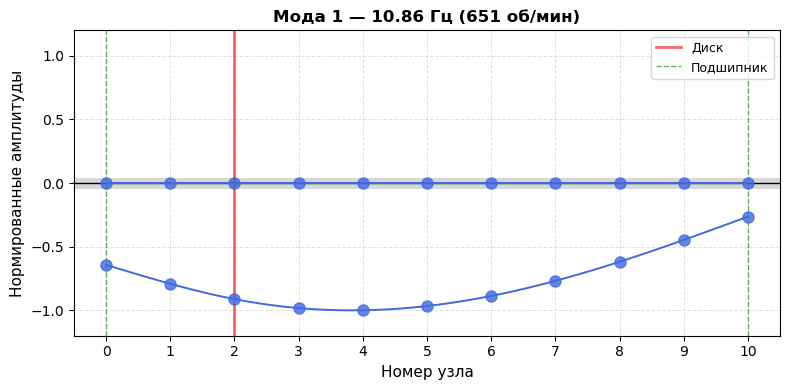

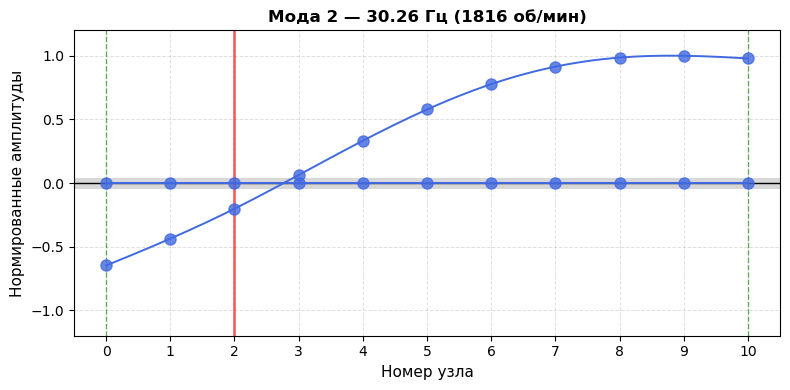

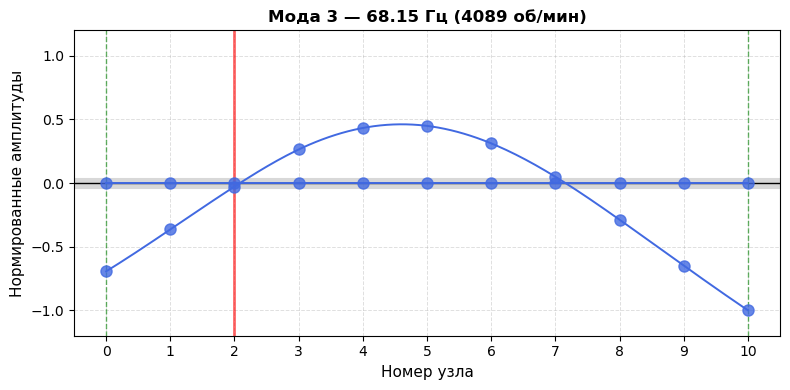

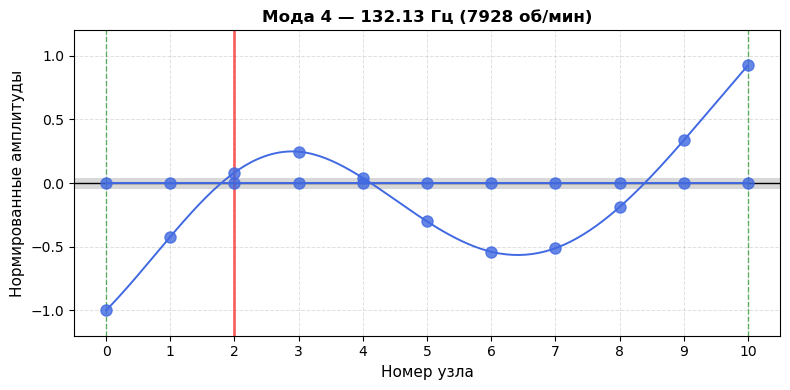

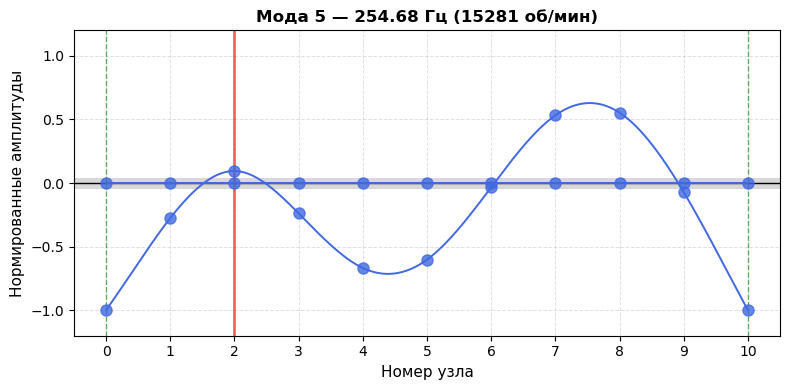

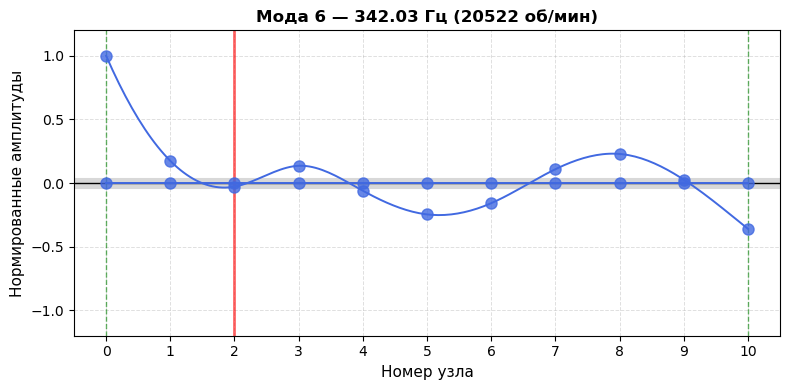

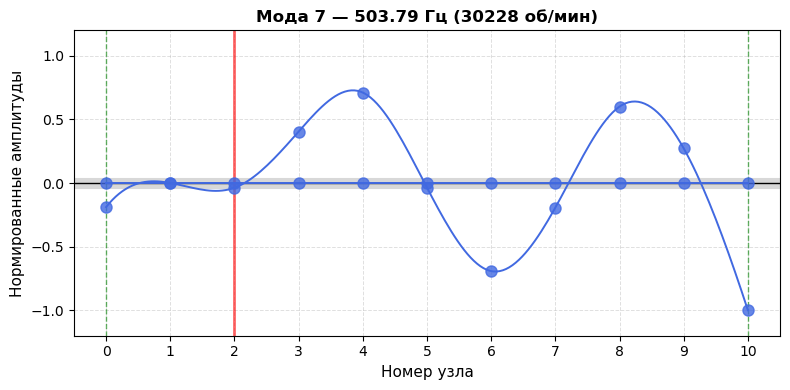

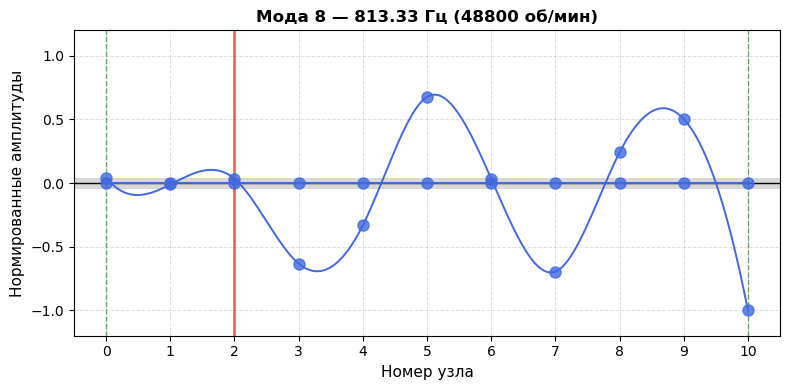

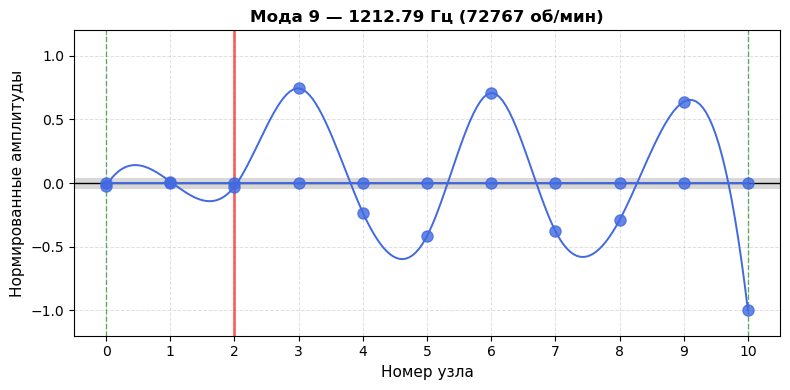

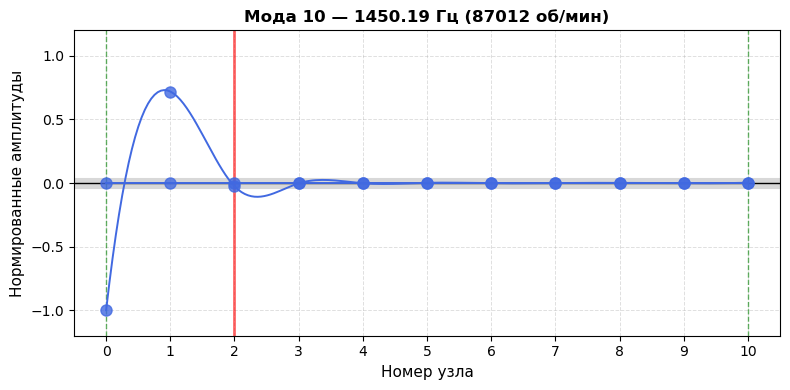

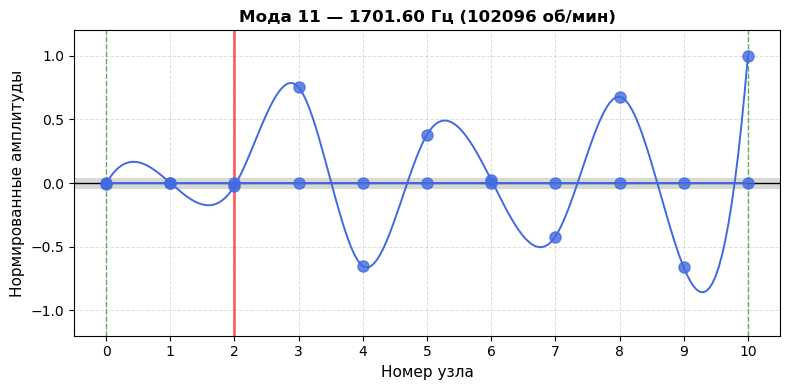

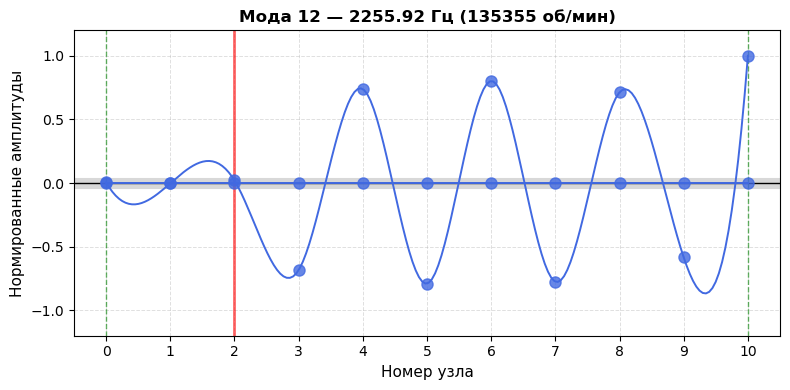

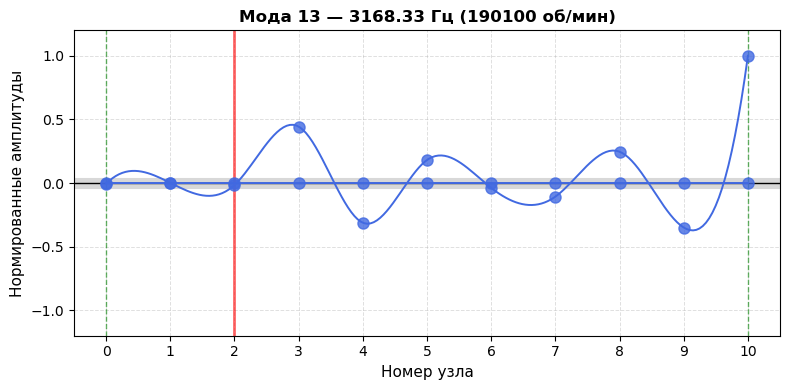

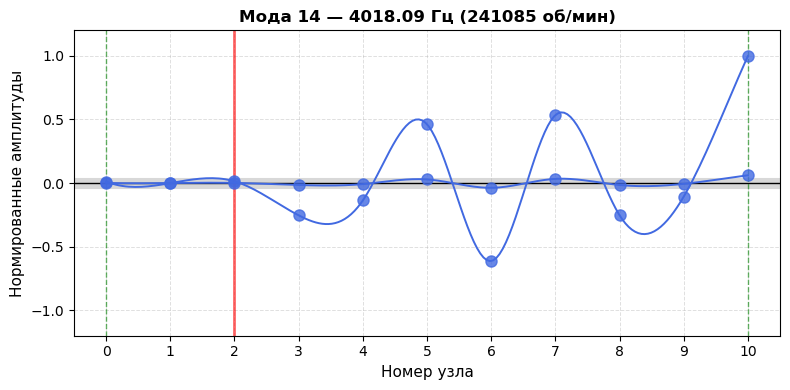

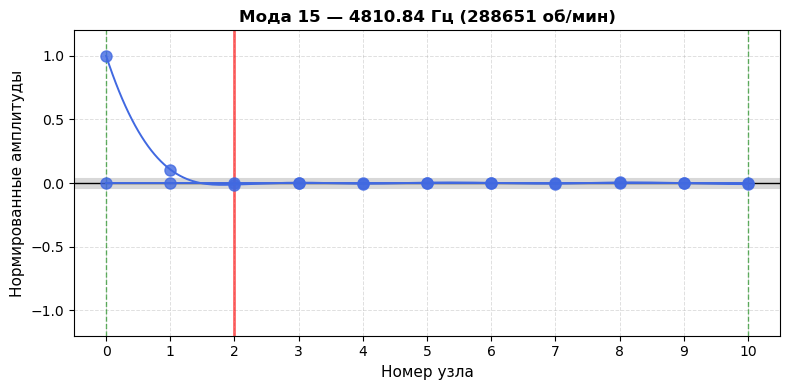

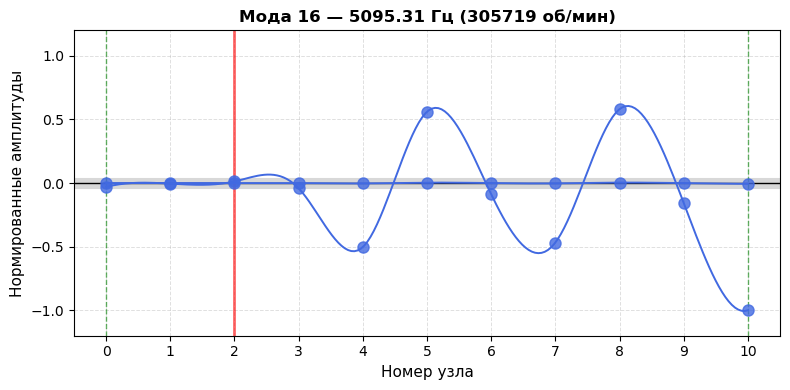

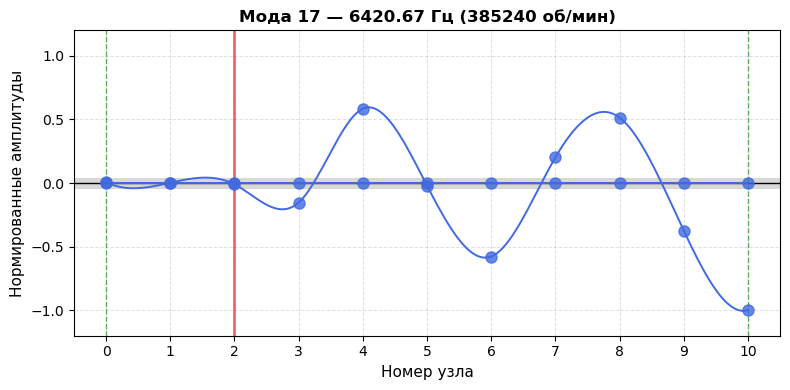

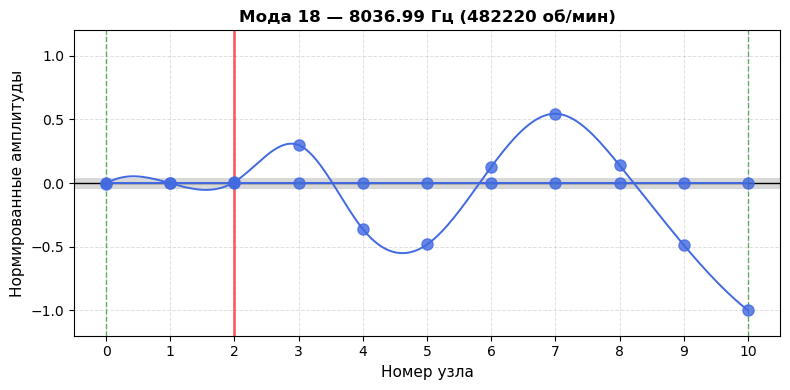

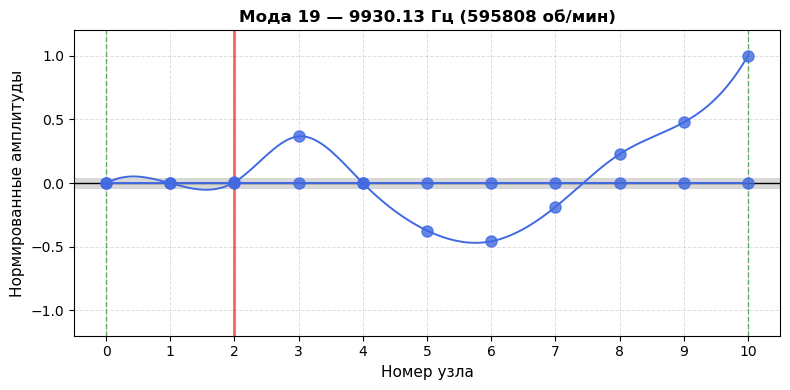

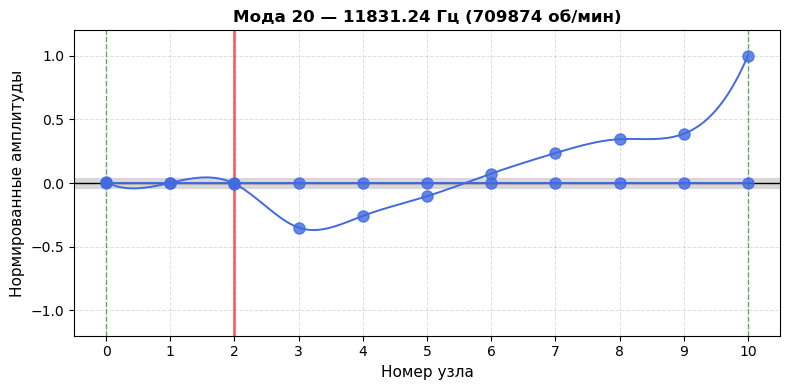

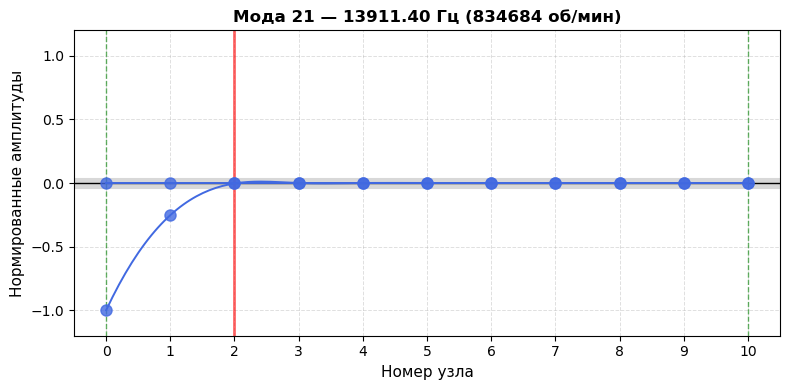

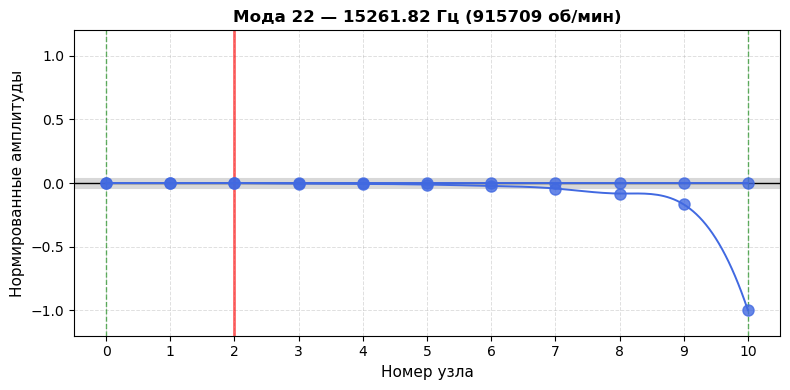


СОБСТВЕННЫЕ ЧАСТОТЫ:
------------------------------------------------------------
 Мода  Частота, Гц  Частота, об/мин
------------------------------------------------------------
    1         10.86           651.45
    2         30.26          1815.60
    3         68.15          4088.79
    4        132.13          7927.91
    5        254.68         15281.00
    6        342.03         20521.89
    7        503.79         30227.50
    8        813.33         48800.03
    9       1212.79         72767.33
   10       1450.19         87011.62
   11       1701.60        102095.78
   12       2255.92        135355.02
  ... и еще 10 мод
Получено 44 собственных частот


In [265]:
def solve_eigen_and_plot(Kf: np.ndarray, Mf: np.ndarray, 
                         free_dofs: np.ndarray, fixed_dofs: np.ndarray,
                         n_nodes: int, Ls: float,
                         disk_nodes: list, bearing_nodes: list,
                         normalize: bool = True, scale_rot: float = 0.1,
                         save_plots: bool = False, out_dir: str = "mode_plots") -> tuple:
    
    # Проверки размерностей
    n_dofs = n_nodes * 4
    if Kf.shape != Mf.shape:
        raise ValueError("Матрицы Kf и Mf должны иметь одинаковую размерность")
    
    print("\n" + "=" * 60)
    print("РЕШЕНИЕ ЗАДАЧИ НА СОБСТВЕННЫЕ ЗНАЧЕНИЯ")
    print("=" * 60)
    
    # Решение обобщенной задачи на собственные значения
    eigvals, eigvecs = eigh(Kf, Mf)
    
    # Обработка собственных значений
    eigvals = np.real(eigvals)
    eigvals[eigvals < 0] = 0.0
    freqs_hz = np.sqrt(eigvals) / (2.0 * np.pi)
    freqs_rpm = freqs_hz * 60
    
    # Сортировка по частоте
    sorted_idx = np.argsort(freqs_hz)
    freqs_hz = freqs_hz[sorted_idx]
    eigvecs = eigvecs[:, sorted_idx]
    
    # Выбор уникальных мод (каждая вторая)
    unique_idx = np.arange(0, len(freqs_hz), 2)    
    n_unique = len(unique_idx)
    freqs_unique = freqs_hz[unique_idx]
    rpm_unique = freqs_rpm[unique_idx]
    
    print(f"Всего собственных частот: {len(freqs_hz)}")
    print(f"Уникальных собственных частот: {n_unique}")
    
    node_numbers = np.arange(n_nodes)           # Массив номеров узлов
    z_coords = np.linspace(0.0, Ls, n_nodes)

    # Восстановление полных форм колебаний
    full_modes = np.zeros((n_dofs, n_unique))
    
    for i, idx in enumerate(unique_idx):
        phi_free = eigvecs[:, idx]
        phi_full = np.zeros(n_dofs)
        phi_full[free_dofs] = np.real(phi_free)
        phi_full[fixed_dofs] = 0.0
        full_modes[:, i] = phi_full
    
    # Построение графиков
    if save_plots:
        import os
        if not os.path.exists(out_dir):
            os.makedirs(out_dir)
    
    print("\nПОСТРОЕНИЕ ФОРМ КОЛЕБАНИЙ")
    print("-" * 40)
    
    for i in range(n_unique):
        
        # Извлечение компонент для текущей моды
        phi_full = full_modes[:, i]
        Ux = phi_full[0::4]
        Uy = phi_full[1::4]
        U_amp = np.sqrt(Ux**2 + Uy**2)

        # Нормировка по выбранной величине (|U|)
        if normalize:
            max_U_amp = np.max(U_amp)
            if max_U_amp == 0:
                max_U_amp = 1.0
            Ux_norm = Ux / max_U_amp
            Uy_norm = Uy / max_U_amp
            U_amp_norm = U_amp / max_U_amp
        else:
            Ux_norm = Ux
            Uy_norm = Uy
            U_amp_norm = U_amp
        
        # Интерполяция сплайнами
        cs_Ux = CubicSpline(z_coords, Ux_norm)
        cs_Uy = CubicSpline(z_coords, Uy_norm)
        cs_U_amp = CubicSpline(z_coords, U_amp_norm)
        
        z_fine = np.linspace(0.0, Ls, 200)
        node_fine = np.linspace(0, n_nodes-1, 200)       # Для гладкого графика по номерам узлов
        
        # Создание графика
        fig, ax = plt.subplots(figsize=(8, 4))

        # Отррисовка вала в исходном положении
        ax.axhline(0, color='black', linestyle='-', linewidth=1)
        ax.axhline(y=0, color='gray', linewidth=8, alpha=0.3, zorder=1)
        
        # График формы колебаний (по номерам узлов):
        ax.plot(node_fine, cs_Ux(z_fine), '-', color='royalblue', linewidth=1.4, zorder=3)
        ax.plot(node_fine, cs_Uy(z_fine), '-', color='royalblue', linewidth=1.4, zorder=3)
        
        # Отрисовка узлов
        ax.plot(node_numbers, Ux_norm, 'o', color='royalblue', markersize=8,
                markeredgecolor='royalblue', markeredgewidth=1, alpha=0.8, zorder=4)
        ax.plot(node_numbers, Uy_norm, 'o', color='royalblue', markersize=8,
                markeredgecolor='royalblue', markeredgewidth=1, alpha=0.8, zorder=4)
        
        # Настройка осей
        ax.set_xlabel('Номер узла', fontsize=11)
        ax.set_ylabel('Нормированные амплитуды', fontsize=11) 
        ax.set_title(f"Мода {i+1} — {freqs_unique[i]:.2f} Гц ({rpm_unique[i]:.0f} об/мин)", 
                    fontsize=12, fontweight='bold')
        
        # Сетка, привязанная к номерам узлов
        ax.set_xticks(np.arange(0, n_nodes))
        ax.set_xticklabels(np.arange(0, n_nodes))
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
        
        # Установка пределов по X для корректного отображения
        ax.set_xlim(-0.5, n_nodes - 0.5)
        
        # Автоматическое определение пределов по Y
        y_max = np.max(np.abs(np.concatenate([Ux_norm, Uy_norm, U_amp_norm]))) * 1.2
        if y_max == 0:
            y_max = 1.0
        ax.set_ylim(-y_max, y_max)
        
        # Вертикальные линии для диска и подшипников
        for node in disk_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='red', linestyle='-', 
                          linewidth=2, alpha=0.6, label='Диск' if node == disk_nodes[0] else "")
        
        for node in bearing_nodes:
            if node < n_nodes:
                ax.axvline(x=node, color='green', linestyle='--', 
                          linewidth=1, alpha=0.6, label='Подшипник' if node == bearing_nodes[0] else "")
                
         # Легенда для первой моды
        if i == 0 and (disk_nodes or bearing_nodes):
        
            ax.legend(loc='upper right', fontsize=9)
        
        plt.tight_layout()
        
        if save_plots:
            plt.savefig(os.path.join(out_dir, f"mode_{i+1:02d}.png"), dpi=200, bbox_inches='tight')
        
        plt.show()
        plt.close(fig)
    
    # Вывод таблицы частот
    print("\nСОБСТВЕННЫЕ ЧАСТОТЫ:")
    print("-" * 60)
    print(f"{'Мода':^6} {'Частота, Гц':^12} {'Частота, об/мин':^15}")
    print("-" * 60)
    
    for i in range(min(n_unique, 12)):
        print(f" {i+1:4d}    {freqs_unique[i]:10.2f}     {rpm_unique[i]:12.2f}")
    
    if n_unique > 12:
        print(f"  ... и еще {n_unique - 12} мод")
    
    print("=" * 60)
    
    return freqs_hz, full_modes


# Запуск решения
freqs, modes = solve_eigen_and_plot(Kf, Mf, free_dofs, fixed_dofs,
                                    n_nodes, Ls,
                                    disk_nodes=[disk_node_idx],
                                    bearing_nodes=bearing_nodes,
                                    normalize=True, scale_rot=0.1,
                                    save_plots=True)

print(f"Получено {len(freqs)} собственных частот")

### ПОСТРОЕНИЕ ДИАГРАММЫ КЭМПБЕЛЛА

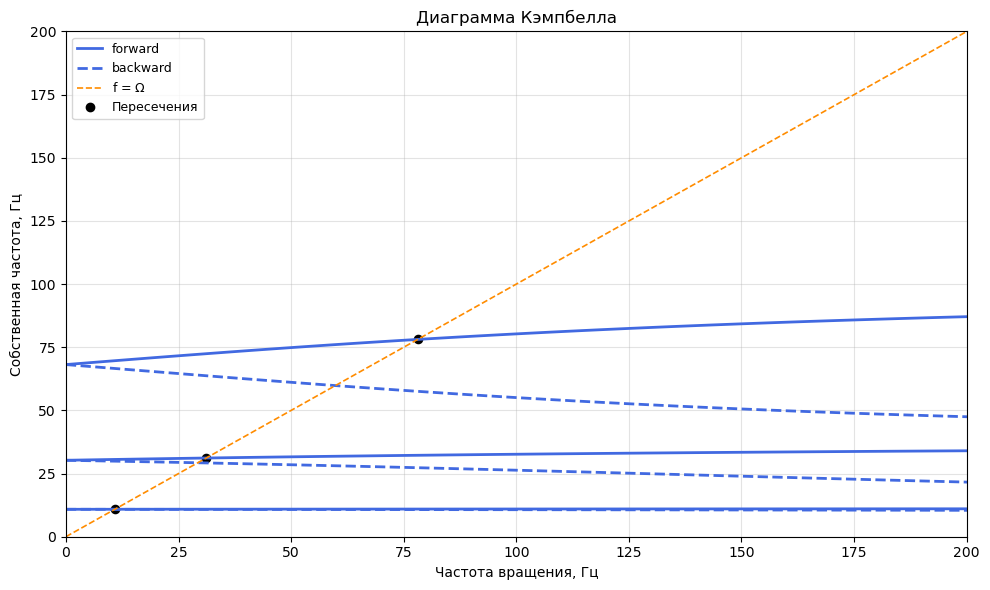

Собственные частоты четных мод при Ω = 0:
 Мода  Частота, Гц
    1    10.857426
    2    30.259971
    3    68.146446
Найденные пересечения (критические скорости):
 mode  order  spin_hz  freq_hz
    1      1   10.872   10.872
    2      1   31.154   31.154
    3      1   78.104   78.104


In [266]:
def qep_eigenfrequencies(M: np.ndarray, C: np.ndarray, K: np.ndarray, n_modes: int = 8) -> np.ndarray:
    """Решение квадратичной задачи: (λ²M + λC + K)φ = 0.
    Возвращает первые n_modes положительных частот (Гц).
    """
    n = M.shape[0]
    Z = np.zeros((n, n))
    I = np.eye(n)

    # Линеаризация QEP в обобщенную задачу A z = λ B z
    A = np.block([
        [Z, I],
        [-K, -C]
    ])
    B = np.block([
        [I, Z],
        [Z, M]
    ])

    lam, _ = eig(A, B)
    lam = lam[np.isfinite(lam)]

    # Для колебательных мод используем ветвь с Im(λ) > 0
    lam_pos = lam[np.imag(lam) > 1e-7]
    freqs = np.imag(lam_pos) / (2 * np.pi)
    freqs = np.real(freqs[freqs > 0])
    freqs = np.sort(freqs)

    if len(freqs) < n_modes:
        out = np.full(n_modes, np.nan)
        out[:len(freqs)] = freqs
        return out

    return freqs[:n_modes]


def find_mode_order_intersections(freq_grid_hz: np.ndarray, mode_map: np.ndarray, n_orders: int = 4) -> pd.DataFrame:
    """Поиск пересечений мод и порядков возбуждения методом линейной интерполяции."""
    intersections = []

    for mode_idx in range(mode_map.shape[0]):
        f_mode = mode_map[mode_idx, :]

        for order in range(1, n_orders + 1):
            f_order = order * freq_grid_hz
            diff = f_mode - f_order

            for j in range(len(freq_grid_hz) - 1):
                d1, d2 = diff[j], diff[j + 1]
                if np.isnan(d1) or np.isnan(d2):
                    continue

                # Попадание точно в узел сетки
                if np.isclose(d1, 0.0, atol=1e-10):
                    intersections.append({
                        'mode': mode_idx + 1,
                        'order': order,
                        'spin_hz': float(freq_grid_hz[j]),
                        'freq_hz': float(f_mode[j])
                    })
                    continue

                # Смена знака на интервале => есть пересечение
                if d1 * d2 < 0:
                    t = d1 / (d1 - d2)
                    freq_cross = freq_grid_hz[j] + t * (freq_grid_hz[j + 1] - freq_grid_hz[j])
                    f_cross = f_mode[j] + t * (f_mode[j + 1] - f_mode[j])
                    intersections.append({
                        'mode': (mode_idx + 1)//2,
                        'order': order,
                        'spin_hz': float(freq_cross),
                        'freq_hz': float(f_cross)
                    })

    if len(intersections) == 0:
        return pd.DataFrame(columns=['mode', 'order', 'spin_hz', 'freq_hz'])

    df = pd.DataFrame(intersections)
    df = df.sort_values(['spin_hz', 'mode', 'order']).reset_index(drop=True)
    return df


def build_campbell_qep(Mf: np.ndarray, Kf: np.ndarray, G0f: np.ndarray,
                        spin_hz_min: float = 0, spin_hz_max: float = 200, n_points: int = 80,
                        n_modes: int = 8, n_orders: int = 4, show_intersections: bool = True,
                        mark_even_only: bool = True):
    freq_grid_hz = np.linspace(spin_hz_min, spin_hz_max, n_points)
    mode_map = np.full((n_modes, n_points), np.nan)

    for j, spin_hz in enumerate(freq_grid_hz):
        Omega = 2 * np.pi * spin_hz
        C = Omega * G0f
        mode_map[:, j] = qep_eigenfrequencies(Mf, C, Kf, n_modes=n_modes)

    intersections_df = find_mode_order_intersections(freq_grid_hz, mode_map, n_orders=n_orders)
    marked_intersections_df = intersections_df.iloc[1::2].reset_index(drop=True) if mark_even_only else intersections_df

    plt.figure(figsize=(10, 6))

    # Модальные ветви: нечётные — сплошные, чётные — пунктир
    for i in range(n_modes):
        linestyle = '--' if (i + 1) % 2 == 1 else '-'
        plt.plot(freq_grid_hz, mode_map[i, :], color='royalblue', linewidth=2, linestyle=linestyle)

    
    # Линии порядков возбуждения (kX)
    for k in range(1, n_orders + 1):
        plt.plot(freq_grid_hz, k * freq_grid_hz, '--', color='darkorange', linewidth=1.2)

    # Маркеры пересечений
    if show_intersections and not marked_intersections_df.empty:
        plt.scatter(marked_intersections_df['spin_hz'], marked_intersections_df['freq_hz'],
                    c='black', s=35, marker='o')

    plt.xlim([0, 200])
    plt.ylim([0, 200])
    plt.title('Диаграмма Кэмпбелла')
    plt.xlabel('Частота вращения, Гц')
    plt.ylabel('Собственная частота, Гц')
    plt.grid(True, alpha=0.35)
    
    legend_handles = [
        Line2D([0], [0], color='royalblue', lw=2, linestyle='-', label='forward'),
        Line2D([0], [0], color='royalblue', lw=2, linestyle='--', label='backward'),
        Line2D([0], [0], color='darkorange', lw=1.2, linestyle='--', label=f'f = $\Omega$'),
        Line2D([0], [0], marker='o', color='black', markerfacecolor='black',
               markersize=6, linestyle='None', label='Пересечения')
    ]

    plt.legend(handles=legend_handles, frameon=True, fontsize=9, ncol=1)

    plt.tight_layout()
    plt.show()

    mode_numbers = np.arange(1, n_modes + 1)
    even_mode_mask = (mode_numbers % 2 == 0)
    omega0_table = pd.DataFrame({
        'Мода': mode_numbers[even_mode_mask]//2,
        'Частота, Гц': mode_map[even_mode_mask, 0]
    })
    print('Собственные частоты четных мод при Ω = 0:')
    print(omega0_table.round({'Собственная частота при Ω = 0, Гц': 3}).to_string(index=False))

    if marked_intersections_df.empty:
        print('Пересечения мод с порядками возбуждения не обнаружены на заданной сетке скоростей.')
    else:
        print('Найденные пересечения (критические скорости):')
        print(marked_intersections_df.round({'spin_hz': 3, 'freq_hz': 3}).to_string(index=False))

    return freq_grid_hz, mode_map, marked_intersections_df


# Подготовка редуцированных матриц
G0f = G0[np.ix_(free_dofs, free_dofs)]
spin_freq_grid_hz, campbell_modes, campbell_intersections = build_campbell_qep(
    Mf=Mf,
    Kf=Kf,
    G0f=G0f,
    spin_hz_min=0,
    spin_hz_max=400,
    n_points=110,
    n_modes=6,
    n_orders=1,
    show_intersections=True,
    mark_even_only=True,
)

In [267]:
# Ординаты (freq_hz) первых трёх точек пересечения
inter_1 = campbell_intersections['freq_hz'].iloc[0] if len(campbell_intersections) > 0 else np.nan
inter_2 = campbell_intersections['freq_hz'].iloc[1] if len(campbell_intersections) > 1 else np.nan
inter_3 = campbell_intersections['freq_hz'].iloc[2] if len(campbell_intersections) > 2 else np.nan

In [268]:
def compute_dynamic_amplification(M, K, G, D, node_disk=None, dof_map=None, Omega_range=None, e_values=None,
                                  M_disk=None, gamma: float = 0.0, g: float = 0.0):
    """
    Расчёт коэффициента динамичности при вынужденных колебаниях от дисбаланса.

    Решаем на каждой частоте:
        (-Ω^2 M + i Ω (D + Ω G) + K) Q = F

    """
    M = np.asarray(M)
    K = np.asarray(K)
    G = np.asarray(G)
    D = np.asarray(D)

    if node_disk is None:
        node_disk = int(np.asarray(disk_node_idx).reshape(-1)[0])
    if dof_map is None:
        dof_map = {"x": 0, "y": 1}
    if Omega_range is None:
        raise ValueError("Omega_range должен быть задан.")
    if e_values is None:
        raise ValueError("e_values должен быть задан.")
    if M_disk is None:
        raise ValueError("M_disk должен быть задан.")

    Omega_values = np.asarray(Omega_range, dtype=float).reshape(-1)
    e_values = np.asarray(e_values, dtype=float).reshape(-1)

    if Omega_values.size == 0:
        raise ValueError("Omega_range не должен быть пустым.")
    if e_values.size == 0:
        raise ValueError("e_values не должен быть пустым.")
    if np.any(e_values <= 0):
        raise ValueError("Все значения e_values должны быть положительными.")

    x_local = int(dof_map.get("x", 0))
    y_local = int(dof_map.get("y", 1))
    dof_x = 4 * int(node_disk) + x_local
    dof_y = 4 * int(node_disk) + y_local

    if dof_x >= M.shape[0] or dof_y >= M.shape[0]:
        raise IndexError("Индексы степеней свободы диска выходят за размер матриц.")

    kd_max = -np.inf
    x_max = -np.inf
    response_by_e = {}

    for e in e_values:
        amplitudes = np.zeros_like(Omega_values, dtype=float)

        for i, omega in enumerate(Omega_values):
            dynamic_matrix = (
                -omega**2 * M
                + 1j * omega * (D + omega * G)
                + K
            ).astype(complex)

            force_real = imbalance_force_vector(
                n_dofs=M.shape[0],
                disk_node_idx=node_disk,
                Md=M_disk,
                e=e,
                Omega=omega,
                gamma=gamma,
                g=g
            ).reshape(-1)
            force = force_real.astype(complex)

            q = np.linalg.solve(dynamic_matrix, force)
            x_amp = np.sqrt(np.abs(q[dof_x])**2 + np.abs(q[dof_y])**2)
            amplitudes[i] = float(x_amp)

        response_by_e[e] = amplitudes
        x_max = max(x_max, float(np.max(amplitudes)))
        kd_max = max(kd_max, float(np.max(amplitudes / e)))

    e_ref = float(np.max(e_values))
    X_by_omega = response_by_e[e_ref]

    return float(kd_max), float(x_max), X_by_omega

# ===== ВЫНУЖДЕННЫЙ ОТКЛИК ОТ ДИСБАЛАНСА: ВЫЗОВ =====

# 1) Рабочая угловая скорость (рад/с)
Omega_work = Omega

# 2) Диапазон ±10% вокруг рабочей скорости (в рад/с)
Omega_range = np.linspace(0.9 * Omega_work, 1.1 * Omega_work, 200)

# 3) Два значения эксцентриситета
e_nom = (2.5 / Omega_work) * 1e-3
e_max = (6.3 / Omega_work) * 1e-3
e_values = [e_nom, e_max]

# 4) Демпфирование в редуцированном виде (в тех же DOF, что Mf/Kf/G0f)
Df = D_b[np.ix_(free_dofs, free_dofs)]

# 5) Расчёт
Kd, X_max, X_by_omega = compute_dynamic_amplification(
    M=Mf,
    K=Kf,
    G=G0f,              
    D=Df,
    Omega_range=Omega_range,
    e_values=e_values,
    M_disk=Md,
    gamma=gamma,        
    g=g                 
)

print(f"Kd = {Kd:.6e}")
print(f"X_max = {X_max:.6e} м")
print(f"X_by_omega shape = {X_by_omega.shape}")

Kd = 1.386245e+01
X_max = 1.115437e-04 м
X_by_omega shape = (200,)


In [269]:
rot_freq_hz_crit = np.array([inter_1, inter_2, inter_3])

# ближайшая
rot_freq_hz_nearest = rot_freq_hz_crit[np.argmin(abs(rot_freq_hz_crit - rot_freq_hz))]

margin = abs(rot_freq_hz_nearest - rot_freq_hz) / rot_freq_hz
margin_percent = margin * 100

print(margin_percent)

37.691363749275766


In [270]:
def check_resonance_margin(Omega_range, Omega_crit):
    min_margin = np.inf

    for Omega in Omega_range:
        # расстояние до всех критических
        distances = np.abs(Omega_crit - Omega) / Omega
        
        # ближайшая
        local_min = np.min(distances)
        
        # обновляем глобальный минимум
        if local_min < min_margin:
            min_margin = local_min

    return min_margin

Omega_crit = np.array([2 * np.pi * inter_1, 2 * np.pi * inter_2, 2 * np.pi * inter_3])

margin = check_resonance_margin(Omega_range, Omega_crit)

print(f"Минимальный запас: {margin*100:.1f}%")

Минимальный запас: 30.8%


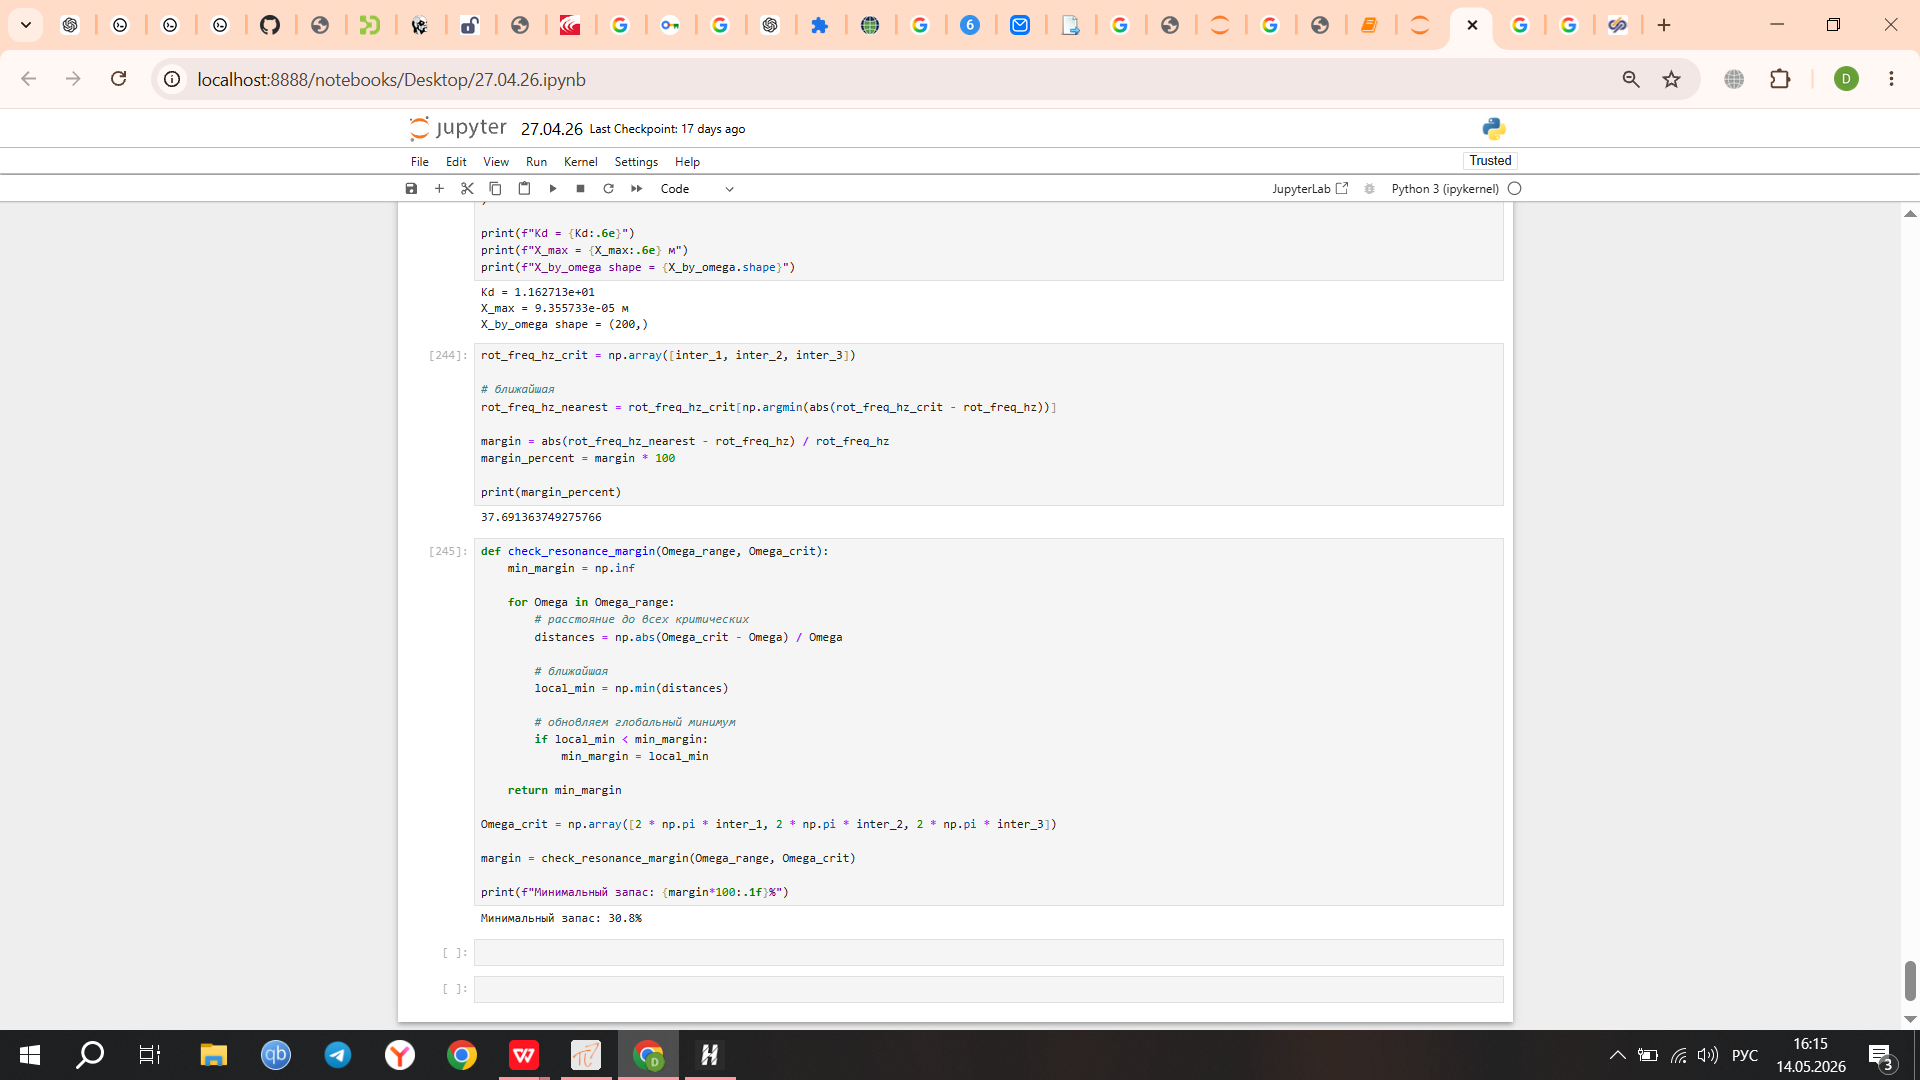

### ФУНКЦИЯ ДЛЯ pSeven: цели и ограничения оптимизации

Ячейка ниже собирает весь расчёт в один вызов `evaluate_design_for_pseven(...)`: переменные оптимизатора преобразуются в физические величины, считаются масса, статический прогиб, критические частоты и максимум коэффициента динамичности по 6 сценариям.



In [ ]:
PENALTY_OBJECTIVE = 1.0e12


def _as_design_dict(design_variables):
    """Преобразовать вход pSeven в словарь множителей проектных переменных."""
    names = ["d_d", "D_d", "h_d", "c_b_l_d", "c_b_r_d", "k_b_l_d", "k_b_r_d", "Ld_d"]
    if isinstance(design_variables, dict):
        return {name: float(design_variables.get(name, globals().get(name, 1.0))) for name in names}

    values = np.asarray(design_variables, dtype=float).reshape(-1)
    if values.size != len(names):
        raise ValueError(f"Ожидалось {len(names)} переменных: {names}, получено {values.size}.")
    return dict(zip(names, values))


def build_design_model(design_variables):
    """
    Пересчитать геометрию, массы и матрицы ротора для одного набора переменных оптимизатора.

    Входные переменные считаются безразмерными множителями к базовым значениям:
    d_d, D_d, h_d, c_b_l_d, c_b_r_d, k_b_l_d, k_b_r_d, Ld_d.
    """
    x = _as_design_dict(design_variables)

    d_loc = d_0 * x["d_d"]
    D_loc = D_0 * x["D_d"]
    h_loc = h_0 * x["h_d"]
    c_b_l_loc = c_b_l_0 * x["c_b_l_d"]
    c_b_r_loc = c_b_r_0 * x["c_b_r_d"]
    k_b_l_loc = k_b_l_0 * x["k_b_l_d"]
    k_b_r_loc = k_b_r_0 * x["k_b_r_d"]
    Ld_loc = Ls * x["Ld_d"]

    if d_loc <= 0 or D_loc <= 0 or h_loc <= 0:
        raise ValueError("Диаметр вала, диаметр диска и ширина диска должны быть положительными.")
    if c_b_l_loc < 0 or c_b_r_loc < 0 or k_b_l_loc < 0 or k_b_r_loc < 0:
        raise ValueError("Жёсткости и демпфирования опор не должны быть отрицательными.")
    if not (0.0 <= Ld_loc <= Ls):
        raise ValueError("Положение диска Ld должно находиться внутри вала: 0 <= Ld <= Ls.")

    A_loc = np.pi * d_loc**2 / 4
    Ix_loc = np.pi * d_loc**4 / 64
    Iy_loc = Ix_loc

    Md_loc = ro * h_loc * np.pi * D_loc**2 / 4
    Jd_loc = Md_loc * D_loc**2 / 16 + Md_loc * h_loc**2 / 12
    Jzz_loc = Md_loc * D_loc**2 / 8
    shaft_mass = ro * Ls * np.pi * d_loc**2 / 4
    total_mass = shaft_mass + Md_loc

    L_elem = Ls / n_elems
    n_nodes_loc = n_elems + 1
    n_dofs_loc = 4 * n_nodes_loc
    disk_node_idx_loc = int(np.clip(round(Ld_loc / L_elem), 0, n_nodes_loc - 1))

    K_element_loc = element_stiffness_matrix(E, Ix_loc, Iy_loc, L_elem)
    K_global_loc = lil_matrix((n_dofs_loc, n_dofs_loc))
    for elem_idx in range(n_elems):
        K_global_loc = assemble_global_stiffness(K_element_loc, elem_idx, elem_idx + 1, K_global_loc)
    K_global_loc = K_global_loc.toarray()
    K_global_loc += build_bearing_stiffness_matrix(n_nodes_loc, n_dofs_loc, k_b_l_loc, k_b_r_loc)

    M_element_loc = element_mass_matrix(ro, A_loc, L_elem)
    M_global_loc = lil_matrix((n_dofs_loc, n_dofs_loc))
    for elem_idx in range(n_elems):
        M_global_loc = assemble_global_mass(M_element_loc, elem_idx, elem_idx + 1, M_global_loc)

    ux = 4 * disk_node_idx_loc
    uy = ux + 1
    rx = ux + 2
    ry = ux + 3
    M_global_loc[ux, ux] += Md_loc
    M_global_loc[uy, uy] += Md_loc
    M_global_loc[rx, rx] += Jd_loc
    M_global_loc[ry, ry] += Jd_loc
    M_global_loc = M_global_loc.toarray()

    G0_loc = build_gyroscopic_matrix(n_dofs_loc, [{'node': disk_node_idx_loc, 'Jp': Jzz_loc}])
    D_loc_matrix = build_bearing_damping_matrix(n_nodes_loc, n_dofs_loc, c_b_l_loc, c_b_r_loc)
    free_dofs_loc = np.arange(n_dofs_loc)

    return {
        "design": x,
        "d": d_loc,
        "D": D_loc,
        "h": h_loc,
        "Ld": Ld_loc,
        "disk_node_idx": disk_node_idx_loc,
        "Md": Md_loc,
        "shaft_mass": shaft_mass,
        "total_mass": total_mass,
        "K": K_global_loc,
        "M": M_global_loc,
        "G0": G0_loc,
        "D_b": D_loc_matrix,
        "free_dofs": free_dofs_loc,
    }


def compute_static_deflection(model):
    """Статический прогиб в узле диска от собственного веса диска."""
    static_force = np.zeros(model["K"].shape[0])
    static_force[4 * model["disk_node_idx"] + 1] = -model["Md"] * g
    q_static = np.linalg.solve(model["K"], static_force)
    return float(abs(q_static[4 * model["disk_node_idx"] + 1])), q_static


def compute_critical_speeds_for_design(model, spin_hz_max=400.0, n_points=110, n_modes=6, n_orders=1):
    """Найти критические скорости как пересечения ветвей Кэмпбелла с порядком возбуждения без построения графиков."""
    free = model["free_dofs"]
    Mf_loc = model["M"][np.ix_(free, free)]
    Kf_loc = model["K"][np.ix_(free, free)]
    G0f_loc = model["G0"][np.ix_(free, free)]

    freq_grid_hz = np.linspace(0.0, spin_hz_max, n_points)
    mode_map = np.full((n_modes, n_points), np.nan)
    for j, spin_hz in enumerate(freq_grid_hz):
        omega_spin = 2 * np.pi * spin_hz
        mode_map[:, j] = qep_eigenfrequencies(Mf_loc, omega_spin * G0f_loc, Kf_loc, n_modes=n_modes)

    intersections = find_mode_order_intersections(freq_grid_hz, mode_map, n_orders=n_orders)
    marked_intersections = intersections.iloc[1::2].reset_index(drop=True)
    critical_hz = marked_intersections["freq_hz"].to_numpy(dtype=float)
    return critical_hz, marked_intersections, mode_map


def evaluate_design_for_pseven(
    design_variables,
    max_static_deflection=1.0e-3,
    min_frequency_margin=0.10,
    frequency_band=0.10,
    spin_hz_max=400.0,
):
    """
    Главная функция для pSeven.

    Возвращает словарь:
    - objective_mass: первая целевая, масса вала + диска, кг;
    - objective_kd: вторая целевая, максимум Kd по 2 эксцентриситетам и 3 частотам;
    - constraint_static_deflection: <= 0, если статический прогиб допустим;
    - constraint_frequency_margin: <= 0, если запас до критических частот допустим.

    Если ограничение не проходит, более дорогие этапы не считаются, а objective_kd получает штраф.
    Если в вашей схеме pSeven ограничение задано как g(x) >= 0, поменяйте знак constraint_*.
    """
    model = build_design_model(design_variables)
    objective_mass = model["total_mass"]

    static_deflection, _ = compute_static_deflection(model)
    constraint_static = static_deflection - max_static_deflection
    if constraint_static > 0.0:
        return {
            "objective_mass": float(objective_mass),
            "objective_kd": PENALTY_OBJECTIVE,
            "constraint_static_deflection": float(constraint_static),
            "constraint_frequency_margin": PENALTY_OBJECTIVE,
            "static_deflection": float(static_deflection),
            "critical_frequencies_hz": np.array([], dtype=float),
            "status": "static_deflection_failed",
        }

    critical_hz, critical_table, _ = compute_critical_speeds_for_design(model, spin_hz_max=spin_hz_max)
    critical_hz = critical_hz[np.isfinite(critical_hz)]
    if critical_hz.size == 0:
        min_margin = -np.inf
    else:
        omega_crit = 2 * np.pi * critical_hz[:3]
        min_margin = check_resonance_margin(np.array([Omega]), omega_crit)

    constraint_margin = min_frequency_margin - min_margin
    if constraint_margin > 0.0:
        return {
            "objective_mass": float(objective_mass),
            "objective_kd": PENALTY_OBJECTIVE,
            "constraint_static_deflection": float(constraint_static),
            "constraint_frequency_margin": float(constraint_margin),
            "static_deflection": float(static_deflection),
            "critical_frequencies_hz": critical_hz[:3],
            "status": "frequency_margin_failed",
        }

    free = model["free_dofs"]
    Mf_loc = model["M"][np.ix_(free, free)]
    Kf_loc = model["K"][np.ix_(free, free)]
    G0f_loc = model["G0"][np.ix_(free, free)]
    Df_loc = model["D_b"][np.ix_(free, free)]

    omega_scenarios = Omega * np.array([1.0 - frequency_band, 1.0, 1.0 + frequency_band])
    e_nom_loc = (2.5 / Omega) * 1e-3
    e_max_loc = (6.3 / Omega) * 1e-3
    kd_max, x_max, _ = compute_dynamic_amplification(
        M=Mf_loc,
        K=Kf_loc,
        G=G0f_loc,
        D=Df_loc,
        node_disk=model["disk_node_idx"],
        Omega_range=omega_scenarios,
        e_values=[e_nom_loc, e_max_loc],
        M_disk=model["Md"],
        gamma=gamma,
        g=g,
    )

    return {
        "objective_mass": float(objective_mass),
        "objective_kd": float(kd_max),
        "constraint_static_deflection": float(constraint_static),
        "constraint_frequency_margin": float(constraint_margin),
        "static_deflection": float(static_deflection),
        "critical_frequencies_hz": critical_hz[:3],
        "max_dynamic_amplitude": float(x_max),
        "status": "ok",
    }


# Пример вызова теми же множителями, что уже заданы выше в ноутбуке.
pseven_result = evaluate_design_for_pseven({
    "d_d": d_d,
    "D_d": D_d,
    "h_d": h_d,
    "c_b_l_d": c_b_l_d,
    "c_b_r_d": c_b_r_d,
    "k_b_l_d": k_b_l_d,
    "k_b_r_d": k_b_r_d,
    "Ld_d": Ld_d,
})
print(pseven_result)



### Обвязка под текущие Responses в pSeven

В таблице pSeven ограничения не прерывают Python-расчёт внутри блока: расчётная точка сначала возвращает все Responses, затем Optimizer помечает её как допустимую или недопустимую по заданным bounds. Поэтому для вашей настройки нужно возвращать именно `Kd`, `margin`, `Ms`, `u`: `u <= 0.0008`, `margin >= 30`, а `Kd` и `Ms` минимизируются.



In [ ]:
def evaluate_pseven_responses(design_variables):
    """
    Обвязка под таблицу Responses на скриншоте pSeven.

    Возвращаемые имена должны совпадать с именами Responses:
    - Kd: целевая на минимум, максимум коэффициента динамичности по 6 сценариям;
    - margin: ограничение pSeven с lower bound 30.0, запас до критической частоты в процентах;
    - Ms: целевая на минимум, масса вала + диска, кг;
    - u: ограничение pSeven с upper bound 0.0008, статический прогиб, м.

    Важно: pSeven сам проверяет bounds после возврата этих чисел. Если u не проходит,
    Optimizer не вызывает какой-то специальный callback "вернуться" — он просто получает
    недопустимую точку, учитывает её в своей модели ограничений и выбирает следующую точку.
    """
    result = evaluate_design_for_pseven(
        design_variables,
        max_static_deflection=8.0e-4,   # соответствует upper bound для u в pSeven
        min_frequency_margin=0.30,      # соответствует lower bound 30% для margin
    )

    margin_percent = np.nan
    if np.isfinite(result.get("constraint_frequency_margin", np.nan)):
        # Внутри evaluate_design_for_pseven: constraint = min_margin_required - actual_margin.
        # Значит actual_margin = min_margin_required - constraint.
        margin_percent = 100.0 * (0.30 - result["constraint_frequency_margin"])

    return {
        "Kd": float(result["objective_kd"]),
        "margin": float(margin_percent),
        "Ms": float(result["objective_mass"]),
        "u": float(result["static_deflection"]),
    }


# Пример для текущей таблицы Variables pSeven.
pseven_outputs = evaluate_pseven_responses({
    "d_d": d_d,
    "D_d": D_d,
    "h_d": h_d,
    "c_b_l_d": c_b_l_d,
    "c_b_r_d": c_b_r_d,
    "k_b_l_d": k_b_l_d,
    "k_b_r_d": k_b_r_d,
    "Ld_d": Ld_d,
})
print(pseven_outputs)



### Как в pSeven реализуется «если не проходит — возврат на оптимизатор»

В pSeven это делается не отдельной командой `return_to_optimizer`, а через **Responses типа Constraint**. Расчётный Python-блок обязан вернуть численные значения всех Responses, после чего Optimizer сам сравнит их с bounds:

1. Optimizer выдаёт очередной набор Variables.
2. Python-блок считает `Ms` и `u`.
3. Если `u > 0.0008`, можно сразу вернуть `u`, `Ms` и штрафные значения для дорогих Responses (`Kd`, `margin`). Так точка будет помечена как infeasible, а модальный и динамический расчёты не будут тратить время.
4. Если `u <= 0.0008`, Python-блок продолжает расчёт: критические частоты, `margin`, затем `Kd`.
5. pSeven получает Responses и автоматически учитывает ограничения `u <= 0.0008` и `margin >= 30` при выборе следующей точки.

Для вашей таблицы Responses используйте функцию `evaluate_pseven_responses(...)`: подключите входы pSeven к одноимённым переменным `d_d`, `D_d`, `h_d`, `k_b_l_d`, `k_b_r_d`, `c_b_l_d`, `c_b_r_d`, `Ld_d`, а выходы функции подключите к Responses `Kd`, `margin`, `Ms`, `u`.

Псевдологика внутри расчётного блока:

```python
out = evaluate_pseven_responses({
    "d_d": d_d,
    "D_d": D_d,
    "h_d": h_d,
    "k_b_l_d": k_b_l_d,
    "k_b_r_d": k_b_r_d,
    "c_b_l_d": c_b_l_d,
    "c_b_r_d": c_b_r_d,
    "Ld_d": Ld_d,
})

Kd = out["Kd"]
margin = out["margin"]
Ms = out["Ms"]
u = out["u"]
```

То есть «возврат на оптимизатор» — это обычное завершение расчётного блока с возвращёнными Responses. Если `u` нарушает upper bound, pSeven сам не использует эту точку как допустимое решение и строит следующую точку оптимизации.

